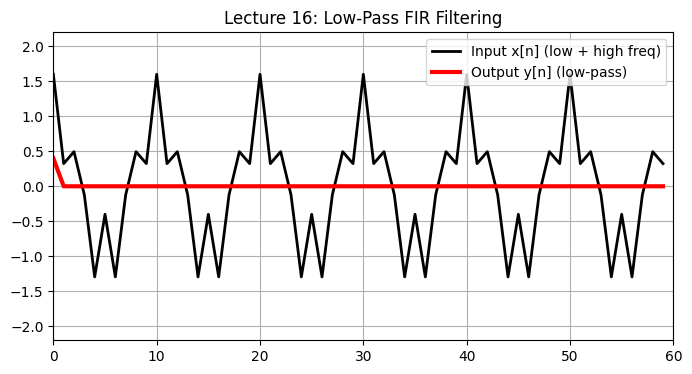

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 16: FIR Frequency Selectivity
# Same animation style as Lecture 9
# -----------------------------

# Time index
N = 60
n = np.arange(N)

# Input signal: low + high frequency components
x_low  = np.cos(0.2 * np.pi * n)     # low frequency
x_high = 0.6 * np.cos(0.8 * np.pi * n)  # high frequency
x = x_low + x_high

# Low-pass FIR filter (symmetric, linear phase)
b = np.array([0.25, 0.5, 0.25])
M = len(b)

# FIR filtering
y = np.zeros(N)
for i in range(N):
    for k in range(M):
        if i - k >= 0:
            y[i] += b[k] * x[i - k]

# Plot setup
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, N)
ax.set_ylim(-2.2, 2.2)
ax.grid(True)
ax.set_title("Lecture 16: Low-Pass FIR Filtering")

# Input signal (static)
ax.plot(n, x, 'k', lw=2, label="Input x[n] (low + high freq)")

# Animated output signal
y_line, = ax.plot([], [], 'r', lw=3, label="Output y[n] (low-pass)")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    y_display = np.zeros(N)
    y_display[:frame+1] = y[:frame+1]

    y_line.set_data(n, y_display)
    return (y_line,)

anim = FuncAnimation(fig, update, frames=N, interval=200)

HTML(anim.to_jshtml())